In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
city_hour = pd.read_csv("city_hour.csv")

city_hour.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01 01:00:00,NaN,NaN,1.00,40.01,36.37,NaN,1.00,122.07,NaN,0.0,0.0,0.0,NaN,NaN
1,Ahmedabad,2015-01-01 02:00:00,NaN,NaN,0.02,27.75,19.73,NaN,0.02,85.90,NaN,0.0,0.0,0.0,NaN,NaN
2,Ahmedabad,2015-01-01 03:00:00,NaN,NaN,0.08,19.32,11.08,NaN,0.08,52.83,NaN,0.0,0.0,0.0,NaN,NaN
3,Ahmedabad,2015-01-01 04:00:00,NaN,NaN,0.30,16.45,9.20,NaN,0.30,39.53,153.58,0.0,0.0,0.0,NaN,NaN
4,Ahmedabad,2015-01-01 05:00:00,NaN,NaN,0.12,14.90,7.85,NaN,0.12,32.63,NaN,0.0,0.0,0.0,NaN,NaN


In [3]:
city_hour.shape

(707875, 16)

In [4]:
city_hour.columns

Index(['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO',
       'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [5]:
city_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 707875 entries, 0 to 707874
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   City        707875 non-null  object 
 1   Datetime    707875 non-null  object 
 2   PM2.5       562787 non-null  float64
 3   PM10        411138 non-null  float64
 4   NO          591243 non-null  float64
 5   NO2         590753 non-null  float64
 6   NOx         584651 non-null  float64
 7   NH3         435333 non-null  float64
 8   CO          621358 non-null  float64
 9   SO2         577502 non-null  float64
 10  O3          578667 non-null  float64
 11  Benzene     544229 non-null  float64
 12  Toluene     487268 non-null  float64
 13  Xylene      252046 non-null  float64
 14  AQI         578795 non-null  float64
 15  AQI_Bucket  578795 non-null  object 
dtypes: float64(13), object(3)
memory usage: 86.4+ MB


In [6]:
city_hour.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,562787.000000,411138.000000,591243.000000,590753.000000,584651.000000,435333.000000,621358.000000,577502.000000,578667.000000,544229.000000,487268.000000,252046.000000,578795.000000
mean,67.622994,119.075804,17.421755,28.885157,32.287565,23.607959,2.183539,14.038307,34.798979,3.087595,8.660927,3.130537,166.413500
std,74.730496,104.224752,32.095211,29.162194,39.756669,28.831900,10.970514,19.305540,29.806379,16.456599,21.741023,7.834832,162.112729
min,0.010000,0.010000,0.010000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,8.000000
25%,26.200000,52.380000,3.840000,10.810000,10.660000,8.120000,0.420000,4.880000,13.420000,0.050000,0.370000,0.100000,79.000000
50%,46.420000,91.500000,7.960000,20.320000,20.790000,15.380000,0.800000,8.370000,26.240000,0.860000,2.590000,0.790000,116.000000
75%,79.490000,147.520000,16.150000,36.350000,37.150000,29.230000,1.370000,14.780000,47.620000,2.750000,8.410000,3.120000,208.000000
max,999.990000,1000.000000,499.990000,499.510000,498.610000,499.970000,498.570000,199.960000,497.620000,498.070000,499.400000,499.990000,3133.000000


In [8]:
city_hour.isnull().sum()

City               0
Datetime           0
PM2.5         145088
PM10          296737
NO            116632
NO2           117122
NOx           123224
NH3           272542
CO             86517
SO2           130373
O3            129208
Benzene       163646
Toluene       220607
Xylene        455829
AQI           129080
AQI_Bucket    129080
dtype: int64

In [9]:
(city_hour.isnull().sum()/len(city_hour))*100

City           0.000000
Datetime       0.000000
PM2.5         20.496274
PM10          41.919407
NO            16.476355
NO2           16.545577
NOx           17.407593
NH3           38.501430
CO            12.222073
SO2           18.417517
O3            18.252940
Benzene       23.117923
Toluene       31.164683
Xylene        64.393996
AQI           18.234858
AQI_Bucket    18.234858
dtype: float64

In [10]:
city_hour.duplicated().sum()

np.int64(0)

In [11]:
city_hour = city_hour.drop_duplicates()

In [12]:
city_hour['Datetime'] = pd.to_datetime(city_hour['Datetime'])

In [13]:
city_hour['Year'] = city_hour['Datetime'].dt.year
city_hour['Month'] = city_hour['Datetime'].dt.month
city_hour['Hour'] = city_hour['Datetime'].dt.hour

In [14]:
city_hour['City'].nunique()

26

In [15]:
city_hour['AQI'].mean()

np.float64(166.4135004621671)

In [16]:
city_hour_aqi = city_hour.groupby('City')['AQI'].mean().sort_values(ascending=False)

city_hour_aqi.head(10)

City
Ahmedabad       453.542641
Delhi           260.148048
Patna           237.929606
Gurugram        223.877409
Lucknow         218.267122
Talcher         177.556503
Jorapokhar      159.990075
Brajrajnagar    151.419829
Kolkata         140.688918
Guwahati        140.246848
Name: AQI, dtype: float64

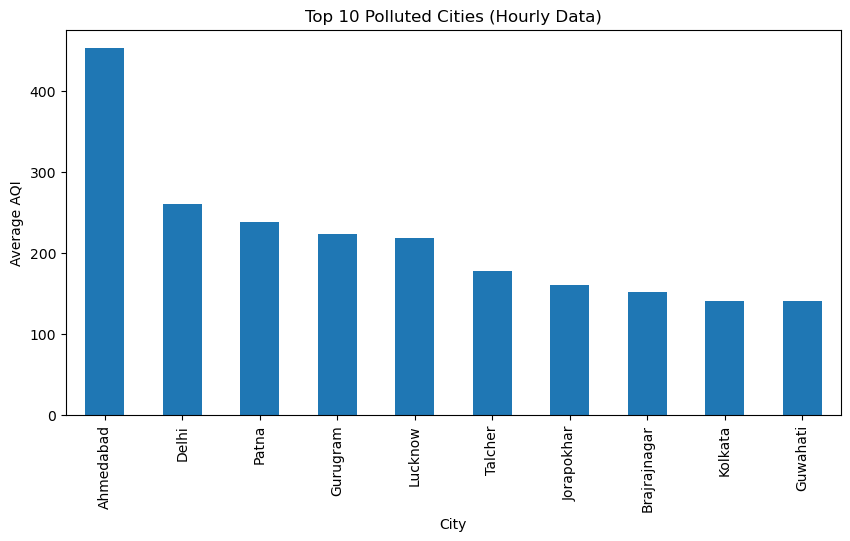

In [17]:
plt.figure(figsize=(10,5))

city_hour_aqi.head(10).plot(kind='bar')

plt.title("Top 10 Polluted Cities (Hourly Data)")
plt.xlabel("City")
plt.ylabel("Average AQI")

plt.show()

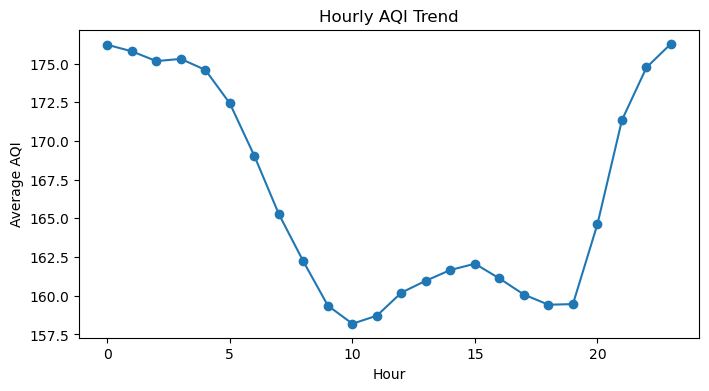

In [18]:
hour_aqi = city_hour.groupby('Hour')['AQI'].mean()

plt.figure(figsize=(8,4))

hour_aqi.plot(kind='line', marker='o')

plt.title("Hourly AQI Trend")
plt.xlabel("Hour")
plt.ylabel("Average AQI")

plt.show()

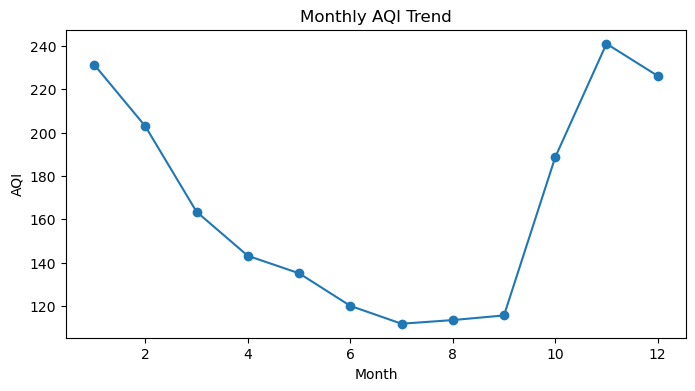

In [19]:
month_aqi = city_hour.groupby('Month')['AQI'].mean()

plt.figure(figsize=(8,4))

month_aqi.plot(marker='o')

plt.title("Monthly AQI Trend")

plt.xlabel("Month")
plt.ylabel("AQI")

plt.show()

In [20]:
city_hour['AQI_Bucket'].value_counts()

AQI_Bucket
Moderate        198991
Satisfactory    189434
Poor             66654
Very Poor        57455
Good             38611
Severe           27650
Name: count, dtype: int64

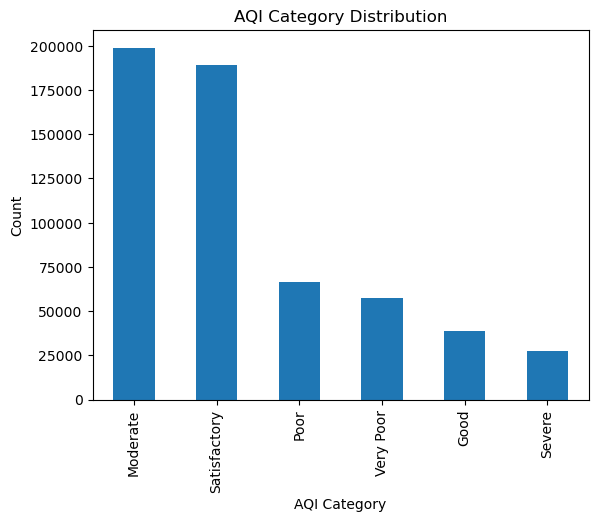

In [21]:
city_hour['AQI_Bucket'].value_counts().plot(kind='bar')

plt.title("AQI Category Distribution")

plt.xlabel("AQI Category")
plt.ylabel("Count")

plt.show()

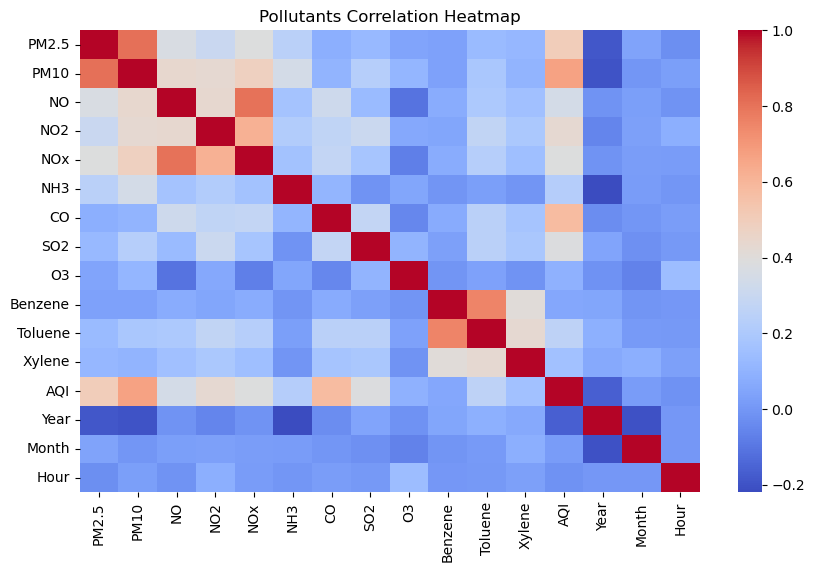

In [22]:
plt.figure(figsize=(10,6))

sns.heatmap(city_hour.corr(numeric_only=True),
            cmap="coolwarm")

plt.title("Pollutants Correlation Heatmap")

plt.show()

In [23]:
city_hour.loc[city_hour['AQI'].idxmax()]

City                    Ahmedabad
Datetime      2017-11-13 00:00:00
PM2.5                       182.8
PM10                          NaN
NO                         498.57
NO2                         33.22
NOx                        388.27
NH3                           NaN
CO                         498.57
SO2                           NaN
O3                          11.14
Benzene                       0.0
Toluene                       0.0
Xylene                        0.0
AQI                        3133.0
AQI_Bucket                 Severe
Year                         2017
Month                          11
Hour                            0
Name: 25127, dtype: object

In [24]:
city_hour.to_csv("Cleaned_City_Hour_Data.csv", index=False)